# 📊 Sales Performance Analysis
### Retail Sales Dataset — 2015 to 2018
**Tools:** Python · Pandas · Matplotlib · Seaborn


---
## 📌 Step 1 — Libraries & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

print('✅ Libraries loaded')

✅ Libraries loaded


In [3]:
df = pd.read_csv('train.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

print(f'Dataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range     : {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print(f'Total Sales    : ${df["Sales"].sum():,.2f}')
df.head()

Dataset shape  : 9,800 rows × 18 columns
Date range     : 2015-01-03 → 2018-12-30
Total Sales    : $2,261,536.78


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


---
## 📌 Step 2 — Data Preparation

In [4]:
# Check missing values
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.any() else '✅ No missing values')

# Extract time features
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

print('\nTime features created.')
print('Years in dataset:', sorted(df['Year'].unique()))

Missing values:
Postal Code    11
dtype: int64

Time features created.
Years in dataset: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


---
## 📌 Step 3 — Sales Analysis & Visualizations

/tmp/ipykernel_615/3137216650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yearly, x='Year', y='Sales', palette='Blues_d')


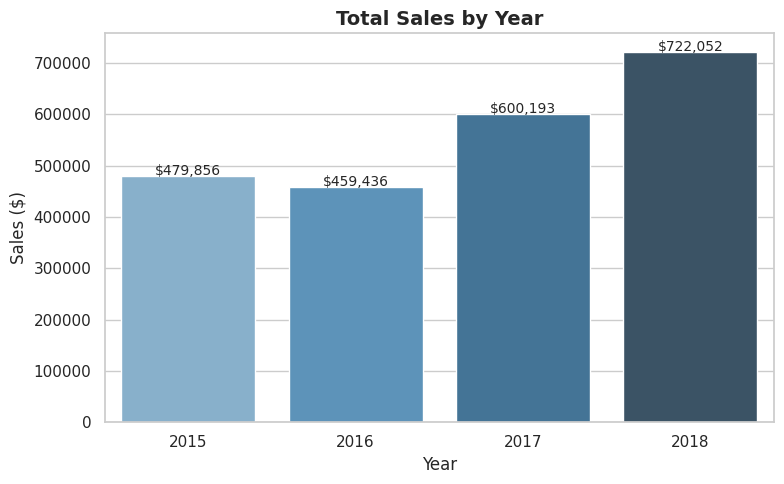

 Year       Sales  YoY Growth (%)
 2015 479856.2081             NaN
 2016 459436.0054       -4.255484
 2017 600192.5500       30.636812
 2018 722052.0192       20.303396


In [5]:
# YoY Sales by Year
yearly = df.groupby('Year')['Sales'].sum().reset_index()
yearly['YoY Growth (%)'] = yearly['Sales'].pct_change() * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=yearly, x='Year', y='Sales', palette='Blues_d')
plt.title('Total Sales by Year', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sales_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(yearly.to_string(index=False))

/tmp/ipykernel_615/1547816714.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=region_sales, x='Region', y='Sales', palette='Set2')


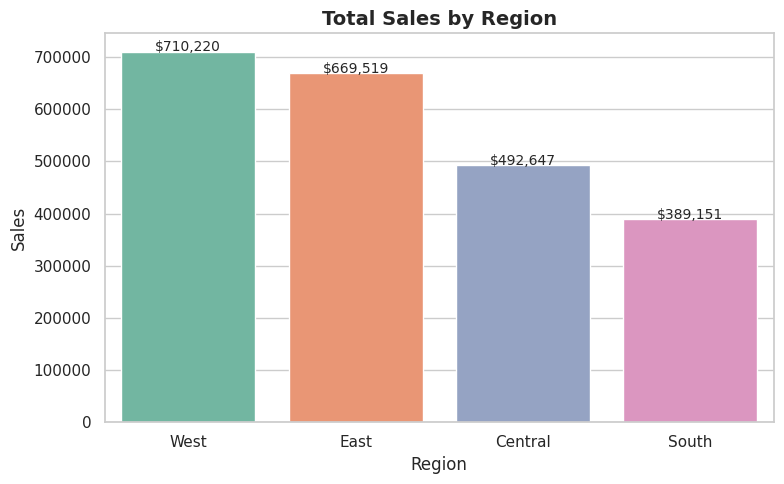

 Region       Sales  Share (%)
   West 710219.6845       31.4
   East 669518.7260       29.6
Central 492646.9132       21.8
  South 389151.4590       17.2


In [6]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales = region_sales.sort_values('Sales', ascending=False)
region_sales['Share (%)'] = (region_sales['Sales'] / region_sales['Sales'].sum() * 100).round(1)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=region_sales, x='Region', y='Sales', palette='Set2')
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sales_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(region_sales.to_string(index=False))

/tmp/ipykernel_615/2669046058.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cat_sales, x='Category', y='Sales', palette='Set1')


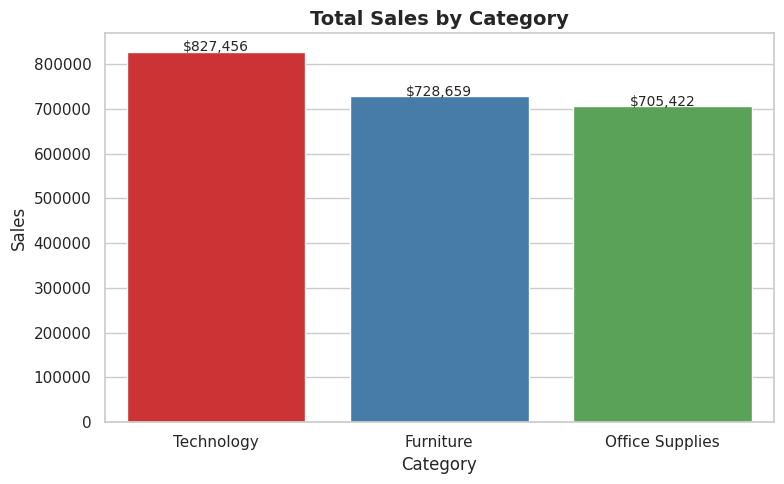

In [7]:
# Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().reset_index()
cat_sales = cat_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=cat_sales, x='Category', y='Sales', palette='Set1')
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

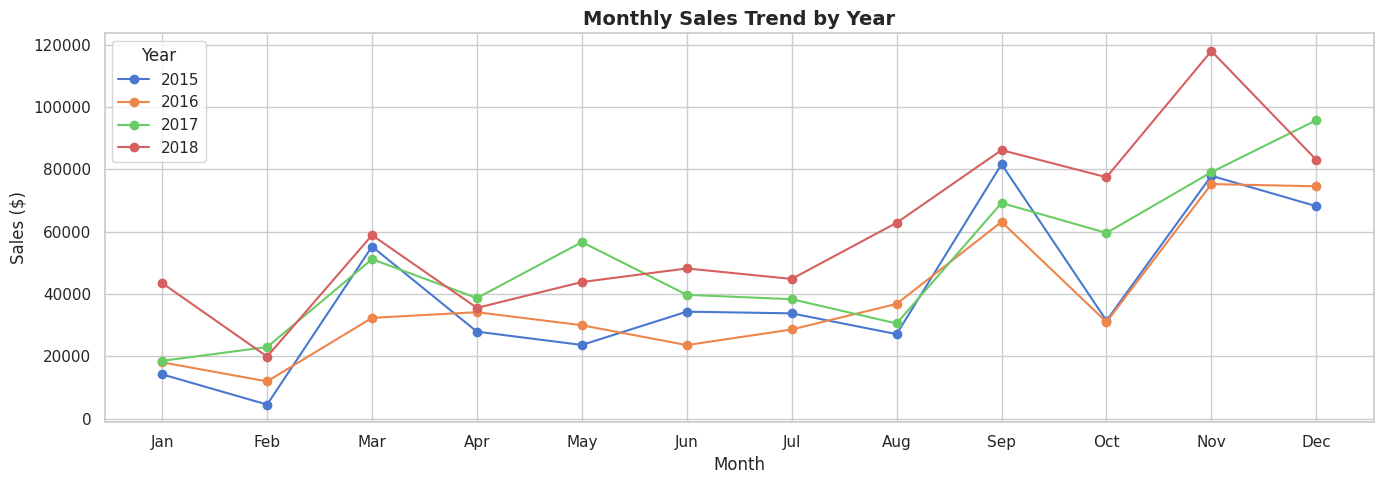

In [8]:
# Monthly Sales Trend (all years)
monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
for year in sorted(monthly['Year'].unique()):
    data = monthly[monthly['Year'] == year]
    plt.plot(data['Month'], data['Sales'], marker='o', label=str(year))

plt.title('Monthly Sales Trend by Year', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_615/4197534691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat, x='Sales', y='Sub-Category', palette='viridis')


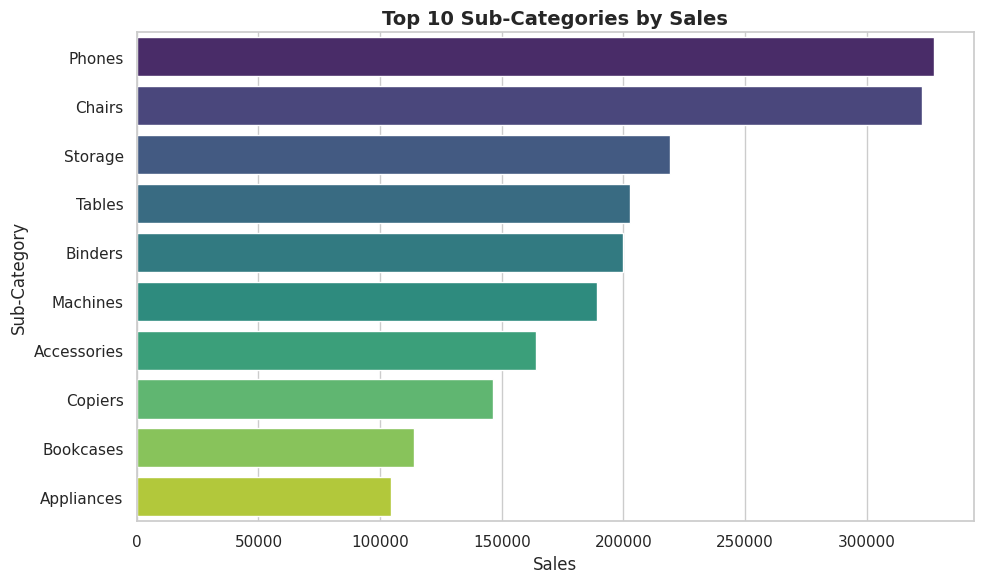

In [9]:
# Top 10 Sub-Categories by Sales
subcat = df.groupby('Sub-Category')['Sales'].sum().reset_index()
subcat = subcat.sort_values('Sales', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=subcat, x='Sales', y='Sub-Category', palette='viridis')
plt.title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_subcategories.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📌 Step 4 — Key Findings

| # | Finding |
|---|---------|
| 1 | **Technology is the top revenue category** — leading Office Supplies and Furniture |
| 2 | **West region leads all regions** in total sales across 4 years |
| 3 | **Q4 (Oct–Dec) consistently peaks** — seasonal demand drives the highest monthly sales |
| 4 | **Sales grew YoY** from 2015 to 2018 across all regions and categories |


In [10]:
print('=== Key Numbers ===')
print(f'Total Transactions : {len(df):,}')
print(f'Total Sales        : ${df["Sales"].sum():,.2f}')
print(f'Top Region         : {region_sales.iloc[0]["Region"]} (${region_sales.iloc[0]["Sales"]:,.2f})')
print(f'Top Category       : {cat_sales.iloc[0]["Category"]} (${cat_sales.iloc[0]["Sales"]:,.2f})')
print(f'Best Year          : {yearly.loc[yearly["Sales"].idxmax(), "Year"]}')

=== Key Numbers ===
Total Transactions : 9,800
Total Sales        : $2,261,536.78
Top Region         : West ($710,219.68)
Top Category       : Technology ($827,455.87)
Best Year          : 2018
